In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import os
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [2]:
colors = [(1, 1, 1), (0.78, 0.84, 0.94), (0.92, 0.69, 0.65)]  # R -> G -> B
n_bins = 20  # Discretizes the interpolation into bins
cmap_name = 'white_blue_red'

# Create the colormap
cmap_wbr = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

In [ ]:
#let's download and import the feature table directly from the FBMN job in GNPS2
task_id = '8be3e6be2924474db9f24be9252dbb54'
response = requests.get(f'https://gnps2.org/result?task={task_id}&viewname=quantificationdownload&resultdisplay_type=task')
directory_path = '/.../temp/'

#import the metadata
metadata = pd.read_csv('/.../Plusrise_Metadata.tsv', sep='\t')
column_interest = 'ATTRIBUTE_SampleType' #this is the column in the metadata table we will work with

with open(directory_path + task_id + '.csv', 'wb') as f:
    f.write(response.content)
    print(f"File saved at {directory_path}")
    
ftable = pd.read_csv(os.path.join(directory_path + task_id + '.csv'), sep=',')
#just keep the column relative to the samples and feature ids
ftable = ftable[[col for col in ftable.columns if col.endswith('Peak area') or col == 'row ID']]

prefix = "MS_"
# formatting table for box plots
ftable = ftable.T
ftable = ftable.reset_index()
ftable.columns = ftable.iloc[0]
ftable = ftable[1:]
ftable = ftable.add_prefix(prefix)
ftable = ftable.rename(columns={'MS_row ID': 'filename'})


In [12]:
#remove .mzML/.mzXML from metadata file and ftable
metadata['filename'] = metadata['filename'].apply(lambda x: x.replace('.mzML', '') if x.endswith('.mzML') else x)
metadata['filename'] = metadata['filename'].apply(lambda x: x.replace('.mzXML', '') if x.endswith('.mzXML') else x)

ftable['filename'] = ftable['filename'].apply(lambda x: x.replace('.mzML Peak area', '') if x.endswith('.mzML Peak area') else x)
ftable['filename'] = ftable['filename'].apply(lambda x: x.replace('.mzXML Peak area', '') if x.endswith('.mzXML Peak area') else x)

#merge and reorganize
ftable_merged = pd.merge(ftable, metadata[['filename', column_interest]],
                                  on='filename', how='left')

ftable_merged.columns = [col.replace('.0', '') if col.endswith('.0') else col for col in ftable_merged.columns]
last_column = ftable_merged.iloc[:, -1]
ftable_merged = pd.concat([last_column, ftable_merged.iloc[:, :-1]], axis=1)

ftable_filtered_merged = ftable_merged[[column_interest, 'filename', 'MS_1643', 'MS_2596', 'MS_17574', 
                                        'MS_10990', 'MS_15833', 'MS_14027']]

# keep only the rows of the samples where we have metadata
ftable_filtered_merged = ftable_filtered_merged[~ftable_filtered_merged[column_interest].isin(['Not available',
                                                                                             'PlateBlank',
                                                                                             '6mix',
                                                                                             'QC_Pool', 'NA',
                                                                                              'Underweight'])]
#and drop NaN
ftable_filtered_merged = ftable_filtered_merged.dropna(subset=[column_interest])


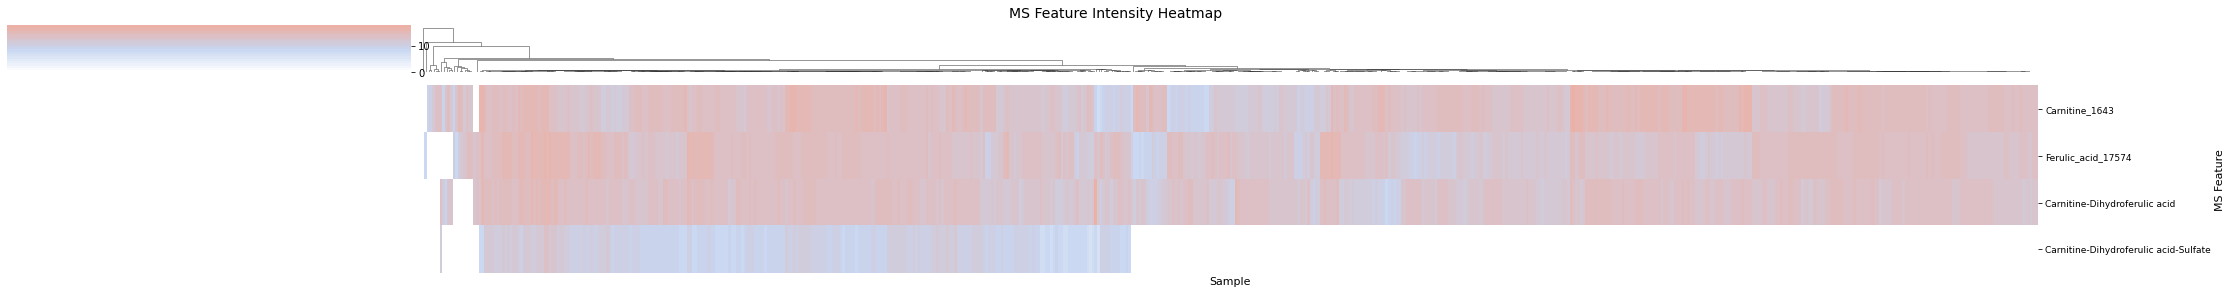

In [ ]:
#plotting the heatmap

#drop sample type column
ftable_filtered_merged = ftable_filtered_merged.drop(columns=[column_interest])
ftable_filtered_merged = ftable_filtered_merged.set_index('filename')

#rename MS features with compound names
rename_map = {
    "MS_1643":  "Carnitine_1643",
    "MS_17574": "Ferulic_acid_17574",
    "MS_15833": "Carnitine-Dihydroferulic acid",
    "MS_14027": "Carnitine-Dihydroferulic acid-Sulfate",
}
ftable_filtered_merged = ftable_filtered_merged.rename(columns=rename_map)

# put in the desired order
ftable_filtered_merged = ftable_filtered_merged.reindex(columns=[
    "Carnitine_1643",
    "Ferulic_acid_17574",
    "Carnitine-Dihydroferulic acid",
    "Carnitine-Dihydroferulic acid-Sulfate"
])

#transpose dataframe for heatmap (rows = MS features, columns = samples)
heatmap_df = ftable_filtered_merged.T 

# Log-transform (log1p handles zeros)
heatmap_log = np.log1p(heatmap_df)

# Plot
n_samples = heatmap_log.shape[1]
n_features = heatmap_log.shape[0]

fig_width = max(14, n_samples * 0.05)   # scale width with sample count
fig_height = max(4, n_features * 0.2)   # scale height with feature count

g = sns.clustermap(
    heatmap_log,
    cmap=cmap_wbr,
    linewidths=0,
    col_cluster=True,
    row_cluster=False,
    metric="braycurtis",
    xticklabels=False,
    yticklabels=True,
    # cbar_kws={"label": "log1p(intensity)", "shrink": 0.6},
    figsize=(fig_width, fig_height),
)

g.fig.suptitle("MS Feature Intensity Heatmap", fontsize=14, y=1.01)
g.ax_heatmap.set_xlabel("Sample", fontsize=11)
g.ax_heatmap.set_ylabel("MS Feature", fontsize=11)

# Rotate x-axis labels for readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=5)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)


plt.tight_layout()
plt.savefig('/.../heatmap.pdf')
plt.show()